In [7]:
# Celda 1 — carga de datos (siempre primero, en cada notebook nuevo)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys; sys.path.append('.')
from conexion_datos import cargar_margen_por_venta

sns.set_style("whitegrid")

df = cargar_margen_por_venta()
df.head()

,id_venta,fecha_venta,nombre_sucursal,ciudad,region,nombre_producto,categoria,cantidad_vendida,precio_venta,costo_unitario,total_venta,margen_total,margen_pct
0,1,2024-09-25,Sucursal Este,Viña del Mar,Valparaíso,Laptop,Electrónica,2,1200.0,800.0,2400.0,800.0,33.3
1,2,2024-07-12,Sucursal Sur,Concepción,Sur,Auriculares,Accesorios,7,70.0,40.0,490.0,210.0,42.9
2,3,2024-12-02,Sucursal Norte,Santiago,Centro,Laptop,Electrónica,6,1200.0,800.0,7200.0,2400.0,33.3
3,4,2024-05-04,Sucursal Sur,Concepción,Sur,Auriculares,Accesorios,7,70.0,40.0,490.0,210.0,42.9
4,5,2024-08-30,Sucursal Sur,Concepción,Sur,Tablet,Electrónica,2,500.0,300.0,1000.0,400.0,40.0


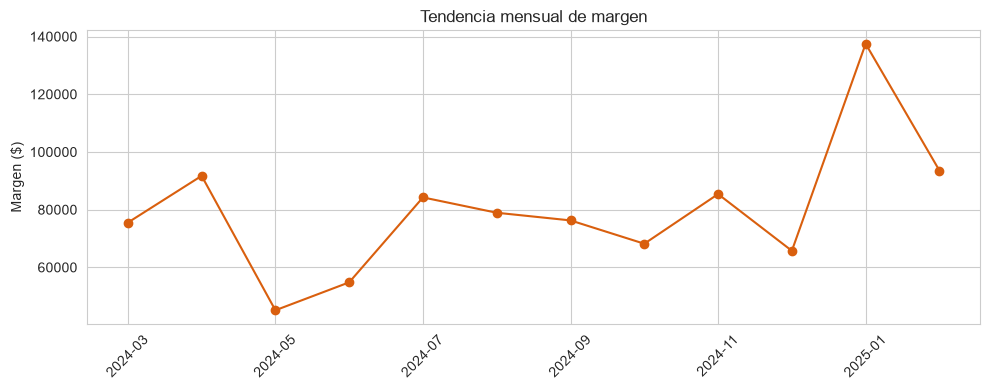

In [8]:
# Celda 2 — tendencia mensual de margen
df['mes'] = pd.to_datetime(df['fecha_venta']).dt.to_period('M').astype(str)
tendencia = df.groupby('mes')['margen_total'].sum()

plt.figure(figsize=(10,4))
tendencia.plot(marker='o', color='#d95f0e')
plt.title('Tendencia mensual de margen')
plt.ylabel('Margen ($)')
plt.xlabel('')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../06_Reportes/img/tendencia_margen_mensual.png', dpi=150)
plt.show()

In [9]:
# Celda 3 — investigar el mes atípico (enero 2025): desagregar por producto y sucursal
enero = df[df['mes'] == '2025-01']

print("Margen enero 2025 por producto:")
print(enero.groupby('nombre_producto')['margen_total'].sum().sort_values(ascending=False))

Margen enero 2025 por producto:
nombre_producto
Laptop         52000.0
Smartphone     39600.0
Tablet         19400.0
Monitor        11520.0
Impresora       6240.0
Teclado         3780.0
Auriculares     3210.0
Mouse           1725.0
Name: margen_total, dtype: float64


In [10]:
# Celda 4 — desagregado por sucursal (¿es una sola sucursal la que dispara el pico?)
print("Margen enero 2025 por sucursal:")
print(enero.groupby('nombre_sucursal')['margen_total'].sum().sort_values(ascending=False))

Margen enero 2025 por sucursal:
nombre_sucursal
Sucursal Sur      36280.0
Sucursal Norte    35790.0
Sucursal Este     32905.0
Sucursal Oeste    32500.0
Name: margen_total, dtype: float64


In [11]:
# Celda 5 — comparar enero contra el promedio mensual de cada producto
promedio_mensual = df.groupby(['nombre_producto', 'mes'])['margen_total'].sum().reset_index()
promedio_por_producto = promedio_mensual.groupby('nombre_producto')['margen_total'].mean()

comparacion = enero.groupby('nombre_producto')['margen_total'].sum().to_frame('margen_enero')
comparacion['promedio_mensual'] = promedio_por_producto
comparacion['variacion_pct'] = round((comparacion['margen_enero'] / comparacion['promedio_mensual'] - 1) * 100, 1)
comparacion.sort_values('variacion_pct', ascending=False)

,margen_enero,promedio_mensual,variacion_pct
nombre_producto,,,
Smartphone,39600.0,18350.00,115.8
Teclado,3780.0,2087.50,81.1
Mouse,1725.0,953.75,80.9
Laptop,52000.0,31900.00,63.0
Monitor,11520.0,7200.00,60.0
Auriculares,3210.0,2100.00,52.9
Impresora,6240.0,4100.00,52.2
Tablet,19400.0,13050.00,48.7
